In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


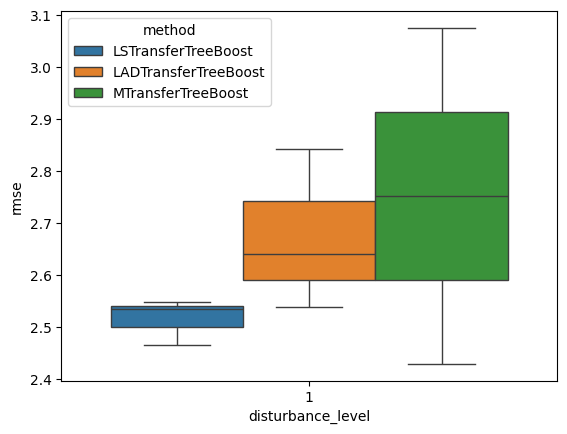

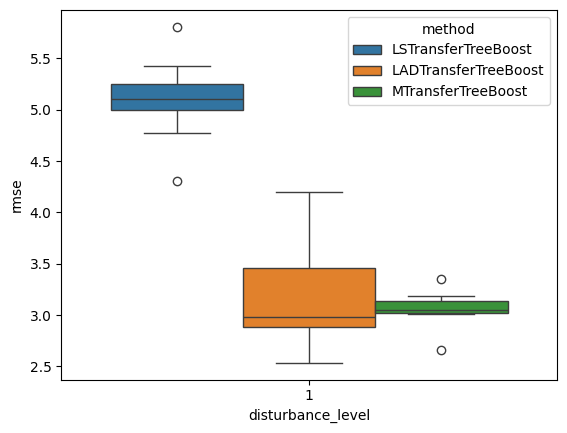

In [59]:
# here we check "sensitivity" to hyperparameter choice!!!!
dat_abl = pd.read_csv('experiments/ablation_transfer_normal_normal_100.csv')
sns.boxplot(data = dat_abl, x = 'disturbance_level', y = 'rmse', hue = 'method')
plt.show()

dat_abl = pd.read_csv('experiments/ablation_transfer_slash_slash_100.csv')
sns.boxplot(data = dat_abl, x = 'disturbance_level', y = 'rmse', hue = 'method')
plt.show()

In [ ]:
#this is for saving optimal hyperparameters, let us use it later!!!!
dat_abl = pd.read_csv('experiments/ablation_transfer_normal_normal_100.csv')
dat_abl = dat_abl.sort_values(by = ['disturbance_level', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs']).reset_index(drop=True)
# Create group indices: 0 for rows 0-2, 1 for 3-5, etc.
group_index = dat_abl.index // 3

# Group by the group index and sum, then broadcast to original rows
dat_abl['total_rmse'] = dat_abl.groupby(group_index)['rmse'].transform('sum')
dat_abl = dat_abl.sort_values(by = ['disturbance_level', 'total_rmse'])
#now, fin best parameters for each disturbance_level (we choose top 3)
optimal_params_transfer = pd.DataFrame(columns = ['disturbance_level', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs'])
for disturbance_level in np.unique(dat_abl['disturbance_level']):
    data_dist = dat_abl[dat_abl['disturbance_level'] == disturbance_level]
    best_params = data_dist[['disturbance_level', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs']].iloc[[0, 3, 6]]
    optimal_params_transfer = pd.concat((optimal_params_transfer, best_params))

optimal_params_transfer.to_csv('optimal_params_transfer.csv')

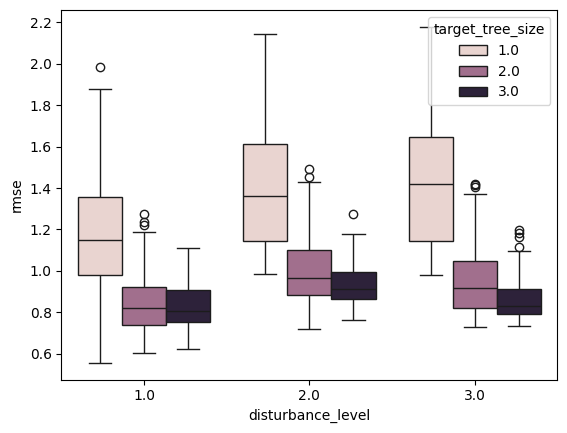

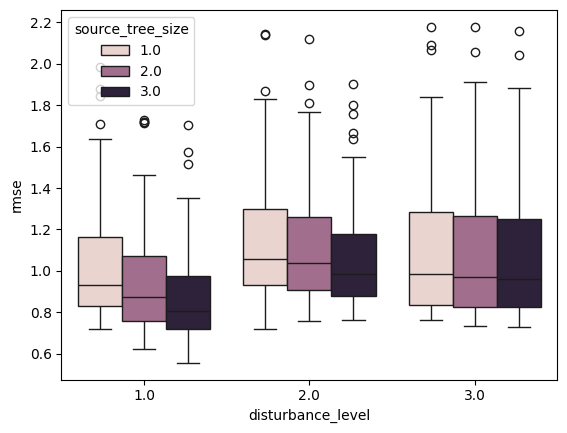

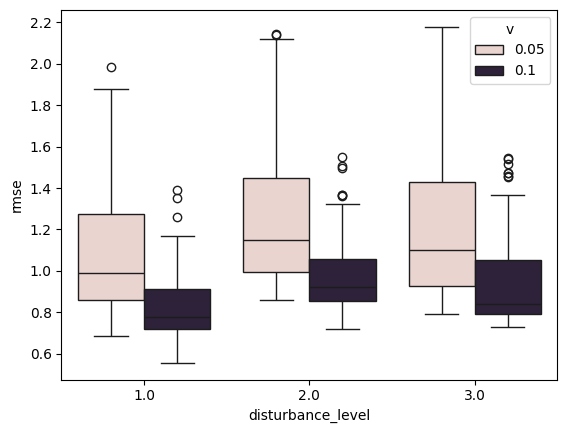

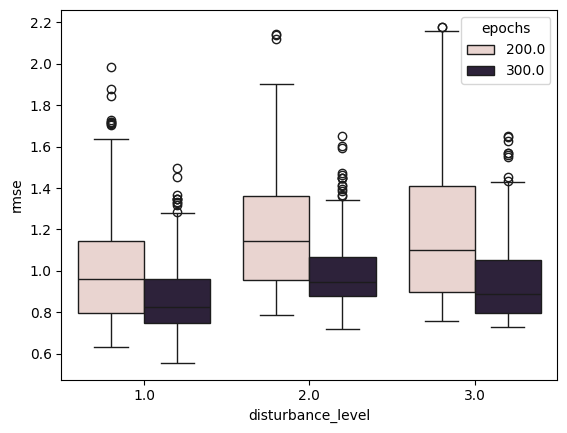

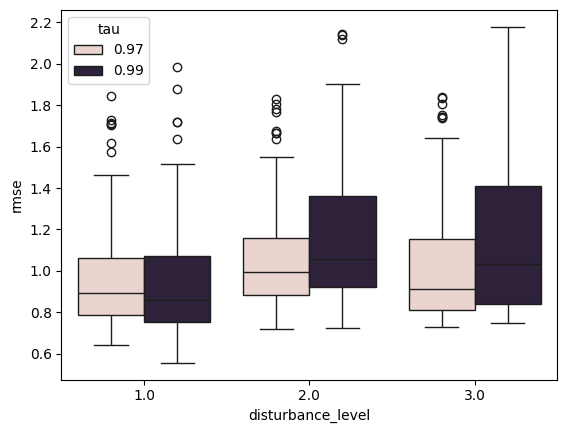

In [19]:
sns.boxplot(data=dat_abl, x = 'disturbance_level', y='rmse', hue='target_tree_size')
plt.show()
sns.boxplot(data=dat_abl, x = 'disturbance_level', y='rmse', hue='source_tree_size')
plt.show()
sns.boxplot(data=dat_abl, x = 'disturbance_level', y='rmse', hue='v')
plt.show()
sns.boxplot(data=dat_abl, x = 'disturbance_level', y='rmse', hue='epochs')
plt.show()
sns.boxplot(data=dat_abl, x = 'disturbance_level', y='rmse', hue='tau')
plt.show()

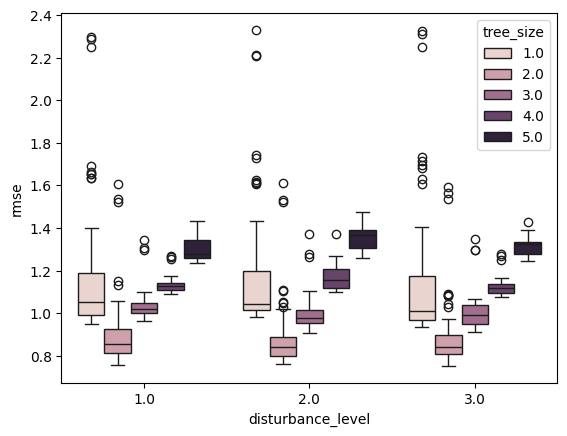

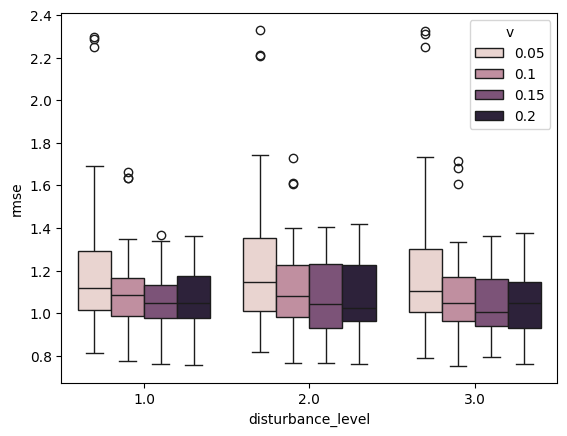

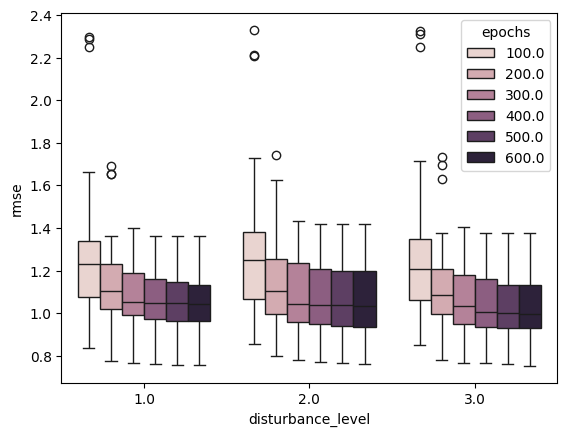

In [18]:
sns.boxplot(data=dat_xgb, x = 'disturbance_level', y='rmse', hue='tree_size')
plt.show()
sns.boxplot(data=dat_xgb, x = 'disturbance_level', y='rmse', hue='v')
plt.show()
sns.boxplot(data=dat_xgb, x = 'disturbance_level', y='rmse', hue='epochs')
plt.show()
